## Generate Dotplots

In [1]:
import os
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

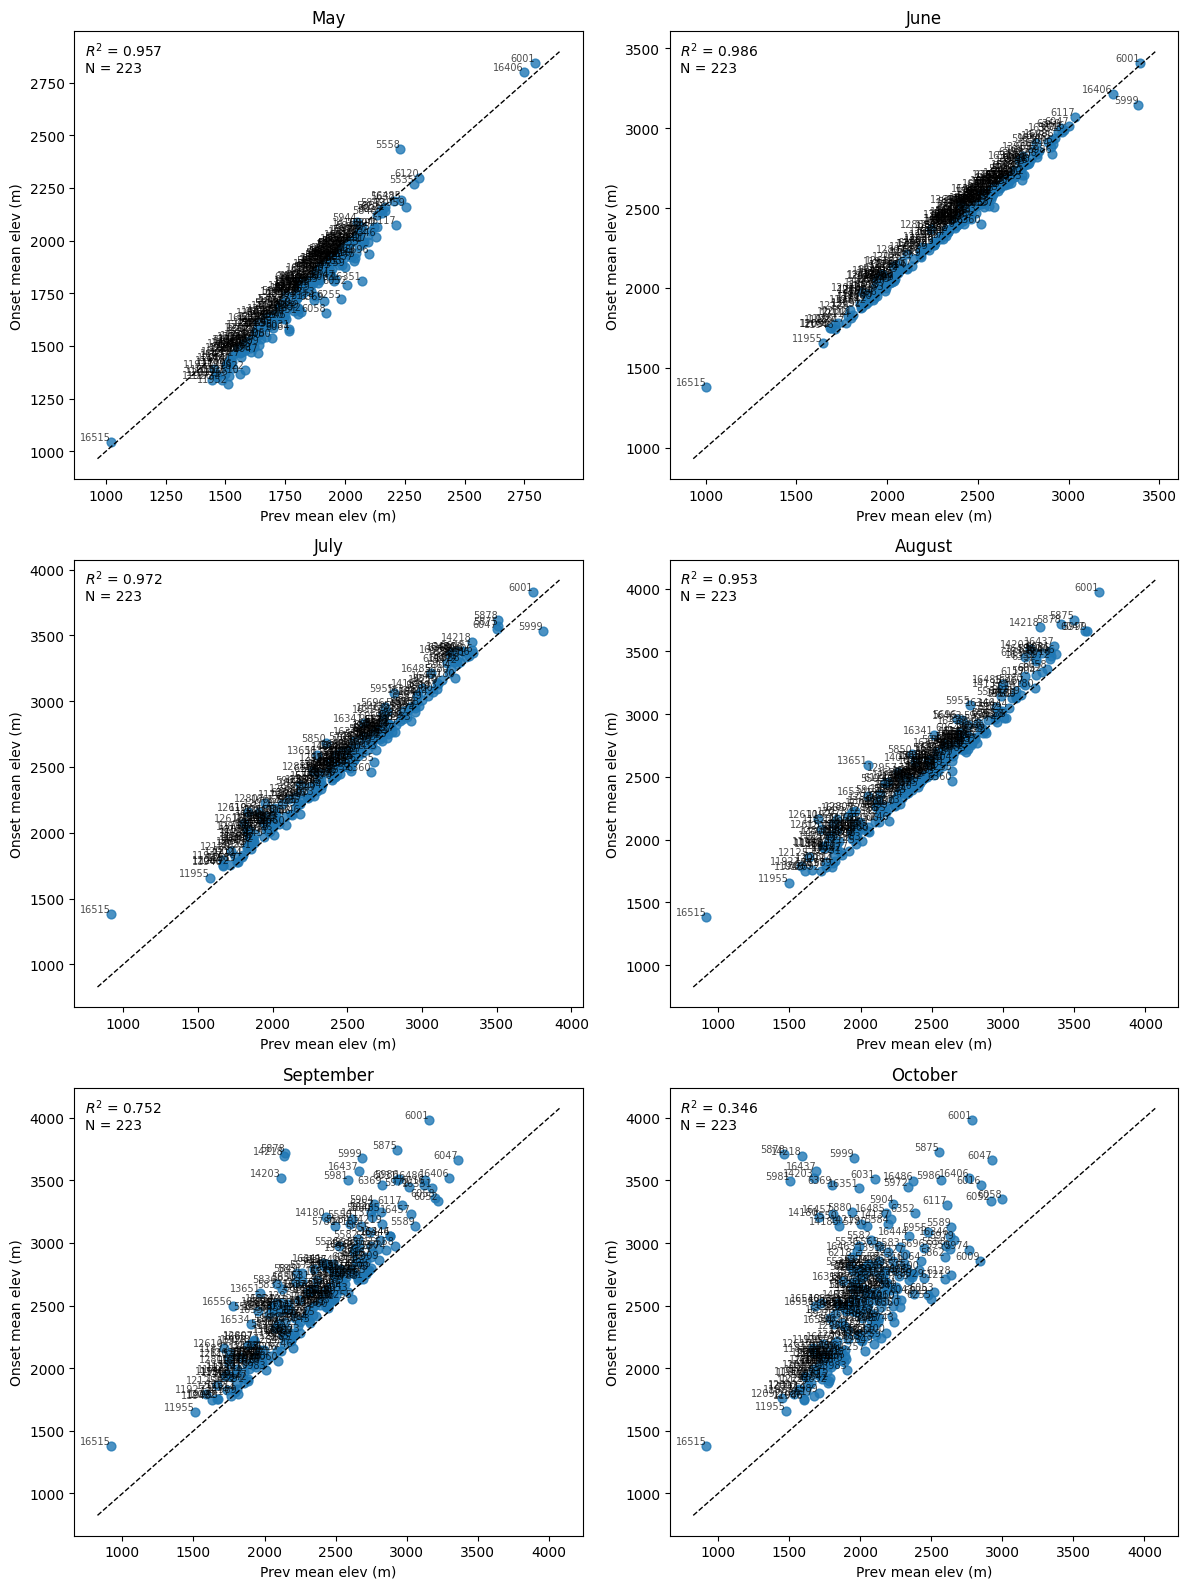

Saved figure: c:\Users\jaden\Downloads\Research\onset_maps\me_monthly_scatter\monthly_prev_vs_onset_elev_may_oct.png
Wrote CSV: c:\Users\jaden\Downloads\Research\onset_maps\me_monthly_scatter\monthly_prev_vs_onset_perglacier_may_oct.csv


In [10]:
multi_root = r"C:\Users\jaden\Downloads\Research\onset_maps\csv"
yearly_dir = r"C:\Users\jaden\Downloads\Research\onset_maps\csv_me_tests"

fig_dir = Path.cwd() / "me_monthly_scatter"
fig_dir.mkdir(parents=True, exist_ok=True)

# -------------------- Patterns / Suffixes ------------------
multi_folder_pat = re.compile(r"^\d{2}\.\d{5}$")  # folders like "01.13075"
multi_elev_suffix = "_melt_extent_elev_percentile_014_387.csv"
# onset yearly file pattern: melt_snowline_time_series_<glac>_<year>.csv
yearly_pattern = re.compile(r"^melt_snowline_time_series_(\d+)_(\d{4})\.csv$")

# months to plot
month_nums = [5, 6, 7, 8, 9, 10]
month_names = {5:"May",6:"June",7:"July",8:"August",9:"September",10:"October"}

# -------------------- Load onset-derived files into dict --------------------
# Build lookup: glacier_id -> list of onset CSV file paths for all years
onset_files_by_glac = {}
for fn in os.listdir(yearly_dir):
    m = yearly_pattern.match(fn)
    if not m:
        continue
    glac = int(m.group(1))
    onset_files_by_glac.setdefault(glac, []).append(os.path.join(yearly_dir, fn))

# -------------------- Helper to load multi elevation CSV for a glacier ------------
def load_prev_elev_for_glacier(folder_path):
    """
    Loads the previous-method elevation CSV for a glacier folder.
    Returns a DataFrame with columns including 'melt_extent_elev_m' and a datetime index.
    Returns None if file missing or empty.
    """
    fname = os.path.basename(folder_path) + multi_elev_suffix
    path = os.path.join(folder_path, fname)
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path, index_col=0)
    # drop rows with empty index, parse dates
    df = df[~df.index.isnull()].copy()
    df.index = pd.to_datetime(df.index, errors="coerce")
    df = df[~df.index.isnull()].copy()
    if "melt_extent_elev_m" not in df.columns:
        return None
    df = df.rename_axis("date").reset_index()
    df["month"] = df["date"].dt.month
    return df  # columns: date, melt_extent_elev_m, ..., month

# -------------------- Helper to load onset CSV and return DataFrame -------------
def load_onset_df(path):
    df = pd.read_csv(path)
    # ensure date exists and is parsed
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
    elif "doy" in df.columns and "year" in df.columns:
        df["date"] = pd.to_datetime(df["doy"], unit="D", origin=df["year"].astype(str) + "-01-01", errors="coerce")
    else:
        # try index
        try:
            df.index = pd.to_datetime(df.index)
            df["date"] = df.index
        except Exception:
            df["date"] = pd.NaT
    # keep only rows with valid date and melt_extent_elev_m if present
    if "melt_extent_elev_m" not in df.columns and "melt_col" in df.columns:
        df["melt_extent_elev_m"] = df["melt_col"]
    if "melt_extent_elev_m" not in df.columns:
        return df  # still return, but will be ignored later
    df = df[~df["date"].isna()].copy()
    if df.empty:
        return df
    df["month"] = df["date"].dt.month
    return df

# -------------------- Aggregate per-glacier, per-month means --------------------
# We'll produce dictionaries:
# prev_month_vals[glac][month] -> list of prev elevation values (all years & dates falling in that month)
# onset_month_vals[glac][month] -> list of onset elevation values (all years & dates falling in that month)

prev_month_vals = {}   # glac -> month -> list
onset_month_vals = {}

# Iterate multi_root folders and collect prev values per glacier
for folder in sorted(os.listdir(multi_root)):
    if not multi_folder_pat.match(folder):
        continue
    folder_path = os.path.join(multi_root, folder)
    if not os.path.isdir(folder_path):
        continue

    # parse glacier id
    try:
        _, glac_str = folder.split(".")
        glacnum = int(glac_str)
    except Exception:
        continue

    prev_df = load_prev_elev_for_glacier(folder_path)
    if prev_df is None or prev_df.empty:
        # No prev data for this glacier
        continue

    prev_month_vals.setdefault(glacnum, {})
    for m in month_nums:
        vals = prev_df.loc[prev_df["month"] == m, "melt_extent_elev_m"].dropna().values
        if vals.size > 0:
            prev_month_vals[glacnum].setdefault(m, []).extend(vals.tolist())

# Iterate onset-derived files and collect onset values per glacier
for glac, paths in onset_files_by_glac.items():
    onset_month_vals.setdefault(glac, {})
    for p in paths:
        df_on = load_onset_df(p)
        if df_on is None or df_on.empty:
            continue
        if "melt_extent_elev_m" not in df_on.columns:
            continue
        for m in month_nums:
            vals = df_on.loc[df_on["month"] == m, "melt_extent_elev_m"].dropna().values
            if vals.size > 0:
                onset_month_vals[glac].setdefault(m, []).extend(vals.tolist())

# -------------------- Build per-month paired arrays across glaciers ----------------
# For each month build arrays x (prev mean per glacier) and y (onset mean per glacier)
per_month_pairs = {m: {"glac": [], "prev_mean": [], "onset_mean": []} for m in month_nums}

# Gather list of unique glaciers from union of both data sources
all_glacs = sorted(set(list(prev_month_vals.keys()) + list(onset_month_vals.keys())))

for glac in all_glacs:
    for m in month_nums:
        prev_vals = prev_month_vals.get(glac, {}).get(m, [])
        onset_vals = onset_month_vals.get(glac, {}).get(m, [])
        # we require both sides to have at least one value to include the glacier for that month
        if len(prev_vals) > 0 and len(onset_vals) > 0:
            prev_mean = float(np.mean(prev_vals))
            onset_mean = float(np.mean(onset_vals))
            per_month_pairs[m]["glac"].append(glac)
            per_month_pairs[m]["prev_mean"].append(prev_mean)
            per_month_pairs[m]["onset_mean"].append(onset_mean)

# -------------------- Plot: one subplot per month in 3x2 grid --------------------
fig, axes = plt.subplots(3, 2, figsize=(12, 16))
axes = axes.flatten()

for idx, m in enumerate(month_nums):
    ax = axes[idx]
    data = per_month_pairs[m]
    x = np.array(data["prev_mean"])
    y = np.array(data["onset_mean"])
    glacs = data["glac"]

    if x.size == 0:
        ax.text(0.5, 0.5, f"No paired data\n({month_names[m]})", ha="center", va="center")
        ax.set_title(month_names[m])
        ax.set_xticks([])
        ax.set_yticks([])
        continue

    # scatter
    ax.scatter(x, y, s=40, alpha=0.8)

    # 1:1 dashed line
    mn = min(np.nanmin(x), np.nanmin(y))
    mx = max(np.nanmax(x), np.nanmax(y))
    pad = 0.03 * (mx - mn) if mx > mn else 10.0
    ax.plot([mn - pad, mx + pad], [mn - pad, mx + pad], 'k--', linewidth=1)

    # annotate R^2 and N
    if x.size > 1:
        r = np.corrcoef(x, y)[0,1]
        r2 = float(r**2)
    else:
        r2 = np.nan
    ax.text(0.02, 0.98, f"$R^2$ = {r2:.3f}\nN = {len(x)}", transform=ax.transAxes,
            verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

    ax.set_title(month_names[m])
    ax.set_xlabel("Prev mean elev (m)")
    ax.set_ylabel("Onset mean elev (m)")

    # Optionally label points with glacier id (small)
    for xi, yi, g in zip(x, y, glacs):
        ax.text(xi, yi, str(g), fontsize=7, alpha=0.7, va='bottom', ha='right')

plt.tight_layout()
outpath = fig_dir / "monthly_prev_vs_onset_elev_may_oct.png"
fig.savefig(outpath, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved figure: {outpath}")

# -------------------- Also write per-month summary CSV --------------------------
rows = []
for m in month_nums:
    for g, pm, om in zip(per_month_pairs[m]["glac"], per_month_pairs[m]["prev_mean"], per_month_pairs[m]["onset_mean"]):
        rows.append({"glac": g, "month": m, "prev_mean_elev_m": pm, "onset_mean_elev_m": om})
summary_df = pd.DataFrame(rows).sort_values(["month","glac"])
summary_csv = fig_dir / "monthly_prev_vs_onset_perglacier_may_oct.csv"
summary_df.to_csv(summary_csv, index=False)
print(f"Wrote CSV: {summary_csv}")

## Area

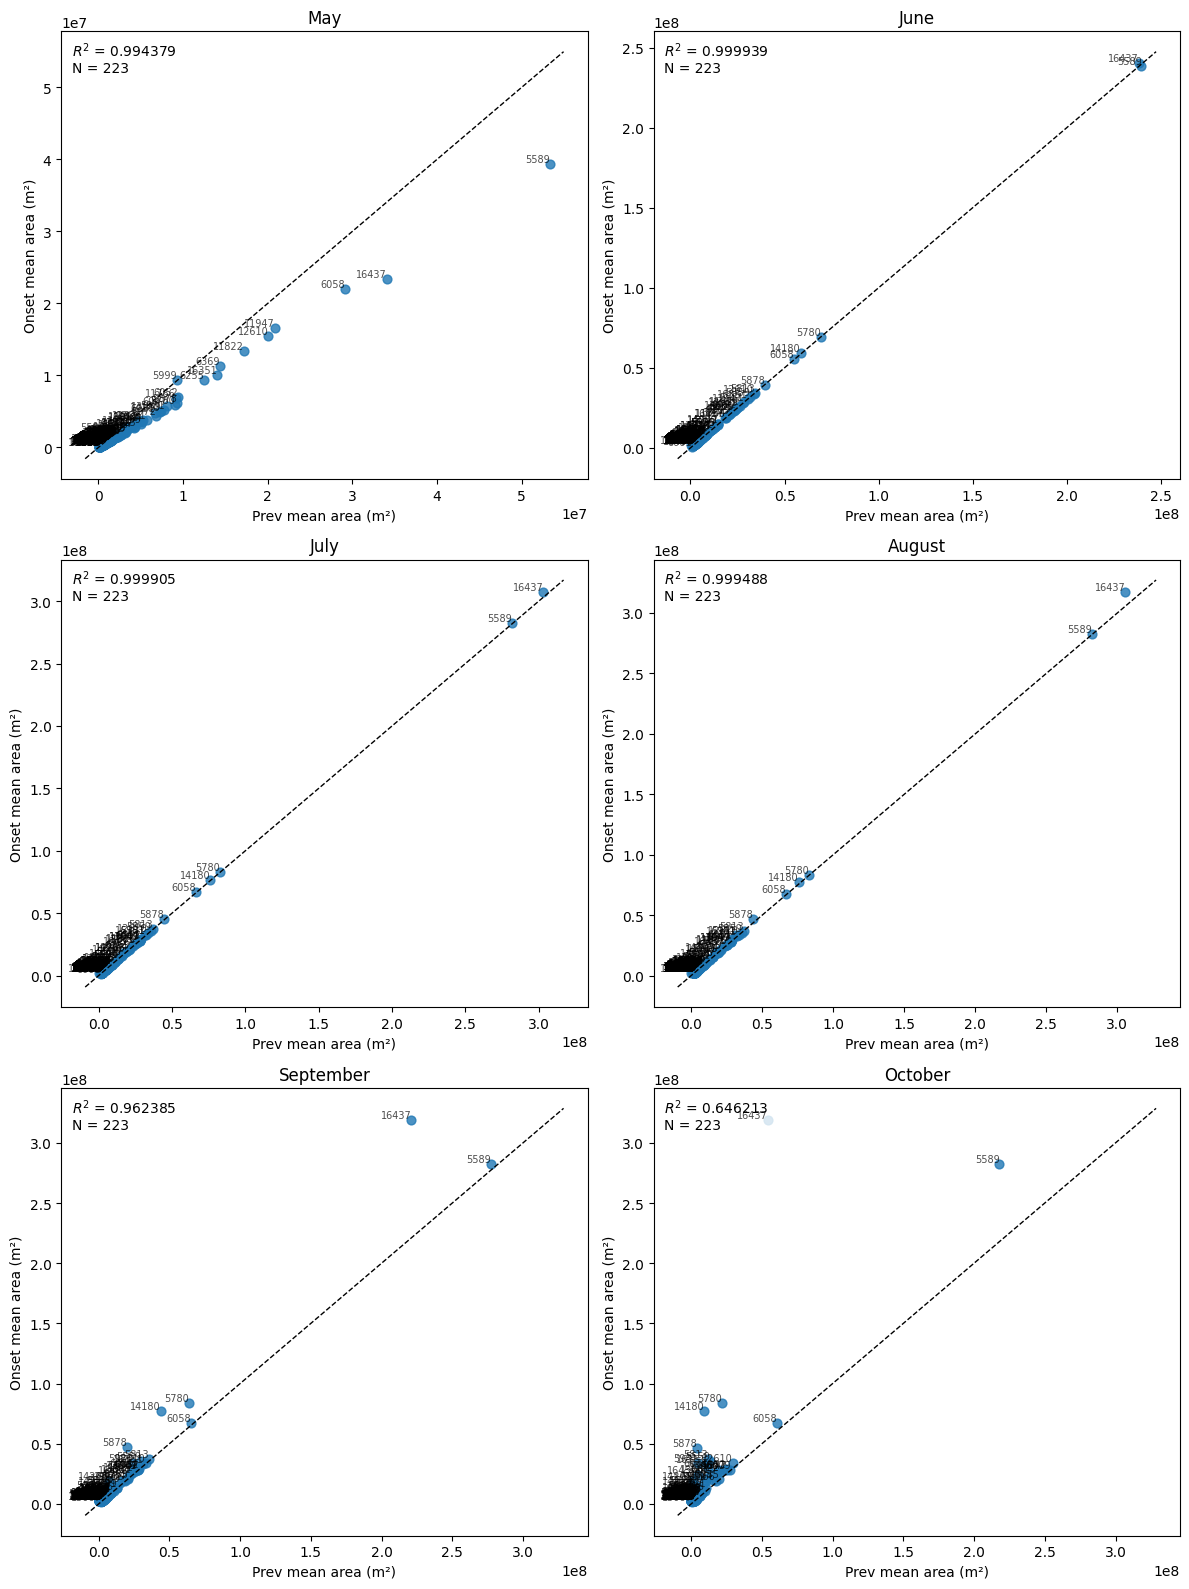

Saved figure: c:\Users\jaden\Downloads\Research\onset_maps\me_monthly_scatter_area\monthly_prev_vs_onset_area_may_oct.png
Wrote CSV: c:\Users\jaden\Downloads\Research\onset_maps\me_monthly_scatter_area\monthly_prev_vs_onset_area_perglacier_may_oct.csv


In [9]:
fig_dir = Path.cwd() / "me_monthly_scatter_area"
fig_dir.mkdir(parents=True, exist_ok=True)

# -------------------- Patterns / Suffixes ------------------
multi_folder_pat = re.compile(r"^\d{2}\.\d{5}$")  # folders like "01.13075"
multi_area_suffix = "_melt_extent_elev_percentile_014_387_eabin.csv"
# onset yearly file pattern: melt_snowline_time_series_<glac>_<year>.csv
yearly_pattern = re.compile(r"^melt_snowline_time_series_(\d+)_(\d{4})\.csv$")

# months to plot
month_nums = [5, 6, 7, 8, 9, 10]
month_names = {5:"May",6:"June",7:"July",8:"August",9:"September",10:"October"}

# -------------------- Load onset-derived files into dict --------------------
# Build lookup: glacier_id -> list of onset CSV file paths for all years
onset_files_by_glac = {}
for fn in os.listdir(yearly_dir):
    m = yearly_pattern.match(fn)
    if not m:
        continue
    glac = int(m.group(1))
    onset_files_by_glac.setdefault(glac, []).append(os.path.join(yearly_dir, fn))

# -------------------- Helper to load multi AREA CSV for a glacier ------------
def load_prev_area_for_glacier(folder_path):
    """
    Loads the previous-method area CSV for a glacier folder.
    Returns a DataFrame with columns including 'melt_extent_area_m2' and a datetime index.
    Returns None if file missing or empty.
    """
    fname = os.path.basename(folder_path) + multi_area_suffix
    path = os.path.join(folder_path, fname)
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path, index_col=0)
    df = df[~df.index.isnull()].copy()
    df.index = pd.to_datetime(df.index, errors="coerce")
    df = df[~df.index.isnull()].copy()
    if "melt_extent_area_m2" not in df.columns:
        return None
    df = df.rename_axis("date").reset_index()
    df["month"] = df["date"].dt.month
    return df  # columns: date, melt_extent_area_m2, ..., month

# -------------------- Helper to load onset CSV and return DataFrame -------------
def load_onset_df(path):
    df = pd.read_csv(path)
    # ensure date exists and is parsed
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
    elif "doy" in df.columns and "year" in df.columns:
        df["date"] = pd.to_datetime(df["doy"], unit="D", origin=df["year"].astype(str) + "-01-01", errors="coerce")
    else:
        # try index
        try:
            df.index = pd.to_datetime(df.index)
            df["date"] = df.index
        except Exception:
            df["date"] = pd.NaT
    # keep melt_area_m2 column if present
    df = df.copy()
    if "melt_area_m2" not in df.columns:
        return df  # still return, will be ignored later
    df = df[~df["date"].isna()].copy()
    if df.empty:
        return df
    df["month"] = df["date"].dt.month
    return df

# -------------------- Aggregate per-glacier, per-month means --------------------
prev_month_vals = {}   # glac -> month -> list of prev area values
onset_month_vals = {}  # glac -> month -> list of onset area values

# Iterate multi_root folders and collect prev area values per glacier
for folder in sorted(os.listdir(multi_root)):
    if not multi_folder_pat.match(folder):
        continue
    folder_path = os.path.join(multi_root, folder)
    if not os.path.isdir(folder_path):
        continue

    # parse glacier id
    try:
        _, glac_str = folder.split(".")
        glacnum = int(glac_str)
    except Exception:
        continue

    prev_df = load_prev_area_for_glacier(folder_path)
    if prev_df is None or prev_df.empty:
        # No prev data for this glacier
        continue

    prev_month_vals.setdefault(glacnum, {})
    for m in month_nums:
        vals = prev_df.loc[prev_df["month"] == m, "melt_extent_area_m2"].dropna().values
        if vals.size > 0:
            prev_month_vals[glacnum].setdefault(m, []).extend(vals.tolist())

# Iterate onset-derived files and collect onset area values per glacier
for glac, paths in onset_files_by_glac.items():
    onset_month_vals.setdefault(glac, {})
    for p in paths:
        df_on = load_onset_df(p)
        if df_on is None or df_on.empty:
            continue
        if "melt_area_m2" not in df_on.columns:
            continue
        for m in month_nums:
            vals = df_on.loc[df_on["month"] == m, "melt_area_m2"].dropna().values
            if vals.size > 0:
                onset_month_vals[glac].setdefault(m, []).extend(vals.tolist())

# -------------------- Build per-month paired arrays across glaciers ----------------
per_month_pairs = {m: {"glac": [], "prev_mean": [], "onset_mean": []} for m in month_nums}

# Gather list of unique glaciers from union of both data sources
all_glacs = sorted(set(list(prev_month_vals.keys()) + list(onset_month_vals.keys())))

for glac in all_glacs:
    for m in month_nums:
        prev_vals = prev_month_vals.get(glac, {}).get(m, [])
        onset_vals = onset_month_vals.get(glac, {}).get(m, [])
        # require both sides to have at least one value to include the glacier for that month
        if len(prev_vals) > 0 and len(onset_vals) > 0:
            prev_mean = float(np.mean(prev_vals))
            onset_mean = float(np.mean(onset_vals))
            per_month_pairs[m]["glac"].append(glac)
            per_month_pairs[m]["prev_mean"].append(prev_mean)
            per_month_pairs[m]["onset_mean"].append(onset_mean)

# -------------------- Plot: one subplot per month in 3x2 grid --------------------
fig, axes = plt.subplots(3, 2, figsize=(12, 16))
axes = axes.flatten()

for idx, m in enumerate(month_nums):
    ax = axes[idx]
    data = per_month_pairs[m]
    x = np.array(data["prev_mean"])
    y = np.array(data["onset_mean"])
    glacs = data["glac"]

    if x.size == 0:
        ax.text(0.5, 0.5, f"No paired data\n({month_names[m]})", ha="center", va="center")
        ax.set_title(month_names[m])
        ax.set_xticks([])
        ax.set_yticks([])
        continue

    # scatter
    ax.scatter(x, y, s=40, alpha=0.8)

    # 1:1 dashed line
    mn = min(np.nanmin(x), np.nanmin(y))
    mx = max(np.nanmax(x), np.nanmax(y))
    pad = 0.03 * (mx - mn) if mx > mn else 1.0
    ax.plot([mn - pad, mx + pad], [mn - pad, mx + pad], 'k--', linewidth=1)

    # annotate R^2 and N
    if x.size > 1:
        r = np.corrcoef(x, y)[0,1]
        r2 = float(r**2)
    else:
        r2 = np.nan
    ax.text(0.02, 0.98, f"$R^2$ = {r2:.6f}\nN = {len(x)}", transform=ax.transAxes,
            verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

    ax.set_title(month_names[m])
    ax.set_xlabel("Prev mean area (m²)")
    ax.set_ylabel("Onset mean area (m²)")

    # Optionally label points with glacier id (small)
    for xi, yi, g in zip(x, y, glacs):
        ax.text(xi, yi, str(g), fontsize=7, alpha=0.7, va='bottom', ha='right')

plt.tight_layout()
outpath = fig_dir / "monthly_prev_vs_onset_area_may_oct.png"
fig.savefig(outpath, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved figure: {outpath}")

# -------------------- Also write per-month summary CSV --------------------------
rows = []
for m in month_nums:
    for g, pm, om in zip(per_month_pairs[m]["glac"], per_month_pairs[m]["prev_mean"], per_month_pairs[m]["onset_mean"]):
        rows.append({"glac": g, "month": m, "prev_mean_area_m2": pm, "onset_mean_area_m2": om})
summary_df = pd.DataFrame(rows).sort_values(["month","glac"])
summary_csv = fig_dir / "monthly_prev_vs_onset_area_perglacier_may_oct.csv"
summary_df.to_csv(summary_csv, index=False)
print(f"Wrote CSV: {summary_csv}")